# EDA

Este notebook explora los datasets para conocer su estructura y tomar decisiones que alimenten las fases siguientes

* Evaluacion de esquemas
* Distribucion de variables
* Proporcion de nulos
* Limpieza e imputacion si asi lo necesitase

In [34]:
# Librerias

import matplotlib.pyplot as plt

from src import clip_palette as cs
cs.apply()
import numpy as np
import pandas as pd
import polars as pl
from collections import Counter


# PATHS

DATA_PATH = "data/"
TXN_PATH = DATA_PATH + "txn_sample.parquet"
PANEL_PATH = DATA_PATH + "merchant_rating_featureset_sample.parquet"

In [35]:
# schema y volumen (lazy)
lf_txn   = pl.scan_parquet(TXN_PATH)
lf_panel = pl.scan_parquet(PANEL_PATH)

print("txn schema:\n",   dict(lf_txn.schema))
print(f"\ntxn filas: {lf_txn.select(pl.len()).collect().item():,}")
print("\npanel schema:\n", dict(lf_panel.schema))
print(f"\npanel filas: {lf_panel.select(pl.len()).collect().item():,}")


# Evaluacion inicial tamaño de los datasets y su intersección

txn_ids   = set(lf_txn.select("merchant_id").unique().collect()["merchant_id"].to_list())
panel_ids = set(lf_panel.select("merchant_id").unique().collect()["merchant_id"].to_list())
inter = txn_ids & panel_ids
union = txn_ids | panel_ids

print(f"txn merchants:    {len(txn_ids):,}")
print(f"panel merchants:  {len(panel_ids):,}")
print(f"intersección:     {len(inter):,}  (jaccard={len(inter)/len(union):.4f})")
print(f"txn sin panel:    {len(txn_ids - panel_ids):,}")
print(f"panel sin txn:    {len(panel_ids - txn_ids):,}")

C:\Users\lautaro.paniagua_roc\AppData\Local\Temp\ipykernel_14844\1416450622.py:5: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print("txn schema:\n",   dict(lf_txn.schema))
C:\Users\lautaro.paniagua_roc\AppData\Local\Temp\ipykernel_14844\1416450622.py:7: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print("\npanel schema:\n", dict(lf_panel.schema))


txn schema:
 {'amount': Float64, 'payment_type': String, 'approved': Int32, 'is_fraud': Int32, 'merchant_id': String, 'transaction_id': String}

txn filas: 7,079,949

panel schema:
 {'observation_date': Date, 'ind_approved_tpv_P95_90d': Float64, 'ind_approved_txn_sum_90d': Float64, 'me_network_avg_tpv_approval_rate': Float64, 'me_network_avg_tpv_chargeback_rate': Float64, 'me_network_avg_tpv_dispute_rate': Float64, 'me_network_size': Int32, 'me_suspended_merchants_in_network': Int64, 'me_suspended_merchants_in_network_share': Float64, 'me_approved_tpv_sum_30d': Float64, 'me_approved_txn_sum_15d': Float64, 'me_approved_txn_sum_1d': Float64, 'me_approved_txn_sum_30d': Float64, 'me_approved_txn_sum_7d': Float64, 'me_attempted_ecommerce_txn_sum_7d': Float64, 'me_attempted_openplatform_txn_sum_7d': Float64, 'me_attempted_pocket_txn_sum_7d': Float64, 'me_attempted_recurring_txn_sum_7d': Float64, 'me_attempted_spei_txn_sum_7d': Float64, 'me_attempted_tpv_avg_1d': Float64, 'me_attempted_tpv_av

In [36]:
# analisis variable is_suspended
panel_susp = (
    lf_panel.select(["merchant_id", "observation_date", "is_suspended"])
    .with_columns(pl.col("observation_date").cast(pl.Date))
    .collect()
)

print("dtype:", panel_susp["is_suspended"].dtype)

print(panel_susp["is_suspended"].value_counts(sort=True))

print("Merchants unicos con almenos una suspensión:", panel_susp.filter(pl.col("is_suspended") == True).select(pl.col("merchant_id").n_unique()).item())


dtype: Boolean
shape: (3, 2)
┌──────────────┬─────────┐
│ is_suspended ┆ count   │
│ ---          ┆ ---     │
│ bool         ┆ u32     │
╞══════════════╪═════════╡
│ false        ┆ 5725618 │
│ null         ┆ 4494219 │
│ true         ┆ 596     │
└──────────────┴─────────┘
Merchants unicos con almenos una suspensión: 26


Alta cantidad de nulos con una muy baja proporcion de valores True

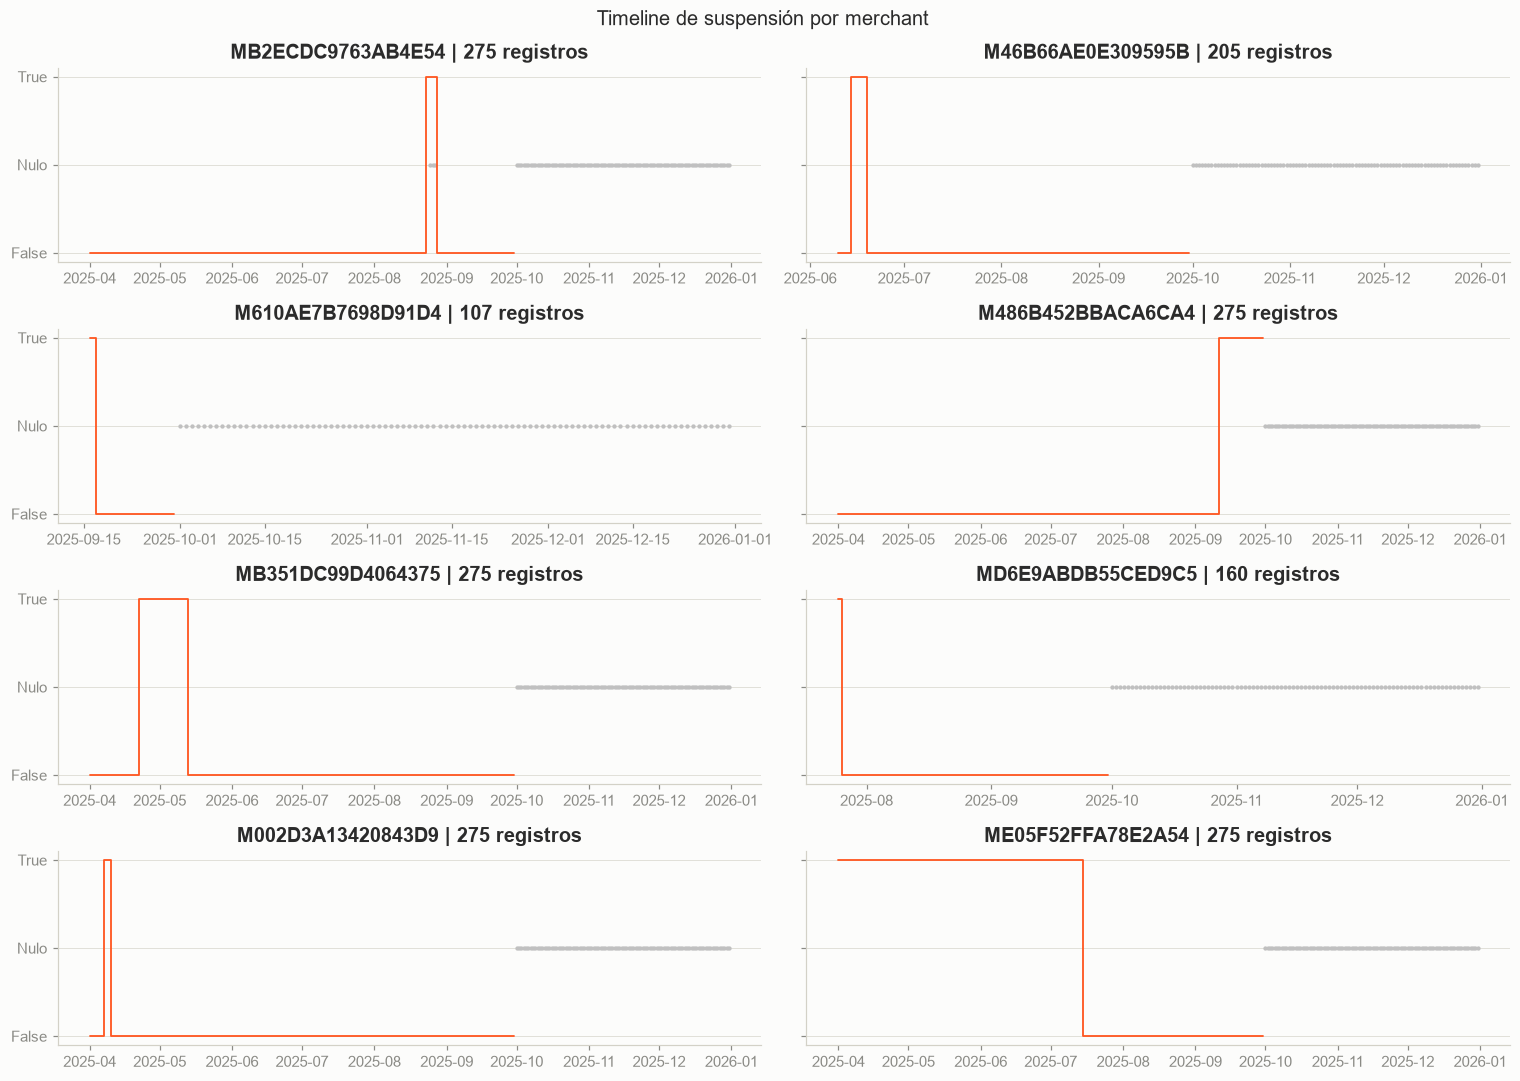

In [37]:
# Merchants que tuvieron al menos una suspensión real
susp_ids = (
    panel_susp
    .filter(pl.col("is_suspended") == True)
    .get_column("merchant_id")
    .unique()
    .to_list()
)

sample_ids = (
    np.random.default_rng(42)
    .choice(susp_ids, size=min(8, len(susp_ids)), replace=False)
    .tolist()
)

sub = (
    panel_susp
    .filter(pl.col("merchant_id").is_in(sample_ids))
    .sort(["merchant_id", "observation_date"])
)

fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharey=True)

for ax, merchant_id in zip(axes.flat, sample_ids):
    merchant = sub.filter(pl.col("merchant_id") == merchant_id)

    dates = merchant["observation_date"].to_list()
    status = merchant["is_suspended"].to_list()

    # La línea se dibuja únicamente donde el valor es conocido
    known_dates = [d for d, value in zip(dates, status) if value is not None]
    known_values = [int(value) for value in status if value is not None]

    ax.step(known_dates, known_values, where="post", linewidth=1.2)

    # Los nulos aparecen como puntos grises en el nivel intermedio
    null_dates = [d for d, value in zip(dates, status) if value is None]
    ax.scatter(
        null_dates,
        [0.5] * len(null_dates),
        s=8,
        color="silver",
        label="Nulo",
    )

    ax.set_title(f"{str(merchant_id)} | {merchant.height} registros")
    ax.set_yticks([0, 0.5, 1], labels=["False", "Nulo", "True"])

plt.suptitle("Timeline de suspensión por merchant")
plt.tight_layout()
plt.show()

In [38]:
susp_id_set = set(susp_ids)

SAMPLE_PCT = 5
panel_sample = (
    lf_panel
    .filter(
        (pl.col("merchant_id").hash(seed=7) % 100 < SAMPLE_PCT)
        | pl.col("merchant_id").is_in(susp_id_set)
    )
    .collect(engine="streaming")
)
print(f"panel_sample: {panel_sample.shape} | merchants {panel_sample['merchant_id'].n_unique():,} "
      f"| fechas {panel_sample['observation_date'].n_unique()} "
      f"| suspendidos {panel_sample.filter(pl.col('merchant_id').is_in(susp_id_set))['merchant_id'].n_unique()}")

# Ratio de fraude por merchant — es el target real, no is_suspended.
fraud_by_merchant = (
    lf_txn.group_by("merchant_id").agg(
        pl.col("amount").sum().alias("_tpv"),
        pl.when(pl.col("is_fraud") == 1).then(pl.col("amount")).otherwise(0).sum().alias("_tpv_fraud"),
        pl.len().alias("_n"),
    )
    .filter(pl.col("_n") >= 10)
    .select("merchant_id", (pl.col("_tpv_fraud") / pl.col("_tpv")).alias("fraud_rate_tpv"))
    .collect()
)


num_cols = [c for c, dt in panel_sample.schema.items() if dt.is_numeric() and c != "is_suspended"]
merchant_lvl = (
    panel_sample.group_by("merchant_id").agg([pl.col(c).mean() for c in num_cols])
    .join(fraud_by_merchant, on="merchant_id", how="inner")
)

# Spearman: el ratio de fraude es 95% ceros y muy sesgado, Pearson no sirve acá.
corr_df = (
    merchant_lvl.select([
        pl.corr(pl.col(c).cast(pl.Float64), pl.col("fraud_rate_tpv"), method="spearman").abs().alias(c)
        for c in num_cols
    ])
    .transpose(include_header=True, header_name="feature", column_names=["abs_corr"])
    .with_columns(pl.col("abs_corr").fill_nan(None))
    .sort("abs_corr", descending=True, nulls_last=True)
)
print(f"\ncorrelación con fraud_rate_tpv sobre {merchant_lvl.height:,} merchants:")
print(corr_df.head(20))

panel_sample: (520566, 71) | merchants 2,052 | fechas 275 | suspendidos 26

correlación con fraud_rate_tpv sobre 1,171 merchants:
shape: (20, 2)
┌─────────────────────────────────┬──────────┐
│ feature                         ┆ abs_corr │
│ ---                             ┆ ---      │
│ str                             ┆ f64      │
╞═════════════════════════════════╪══════════╡
│ me_lifetime_chargeback_tpv      ┆ 0.531361 │
│ ratio_claims_tpv_180d           ┆ 0.436514 │
│ me_lifetime_dispute_tpv         ┆ 0.367193 │
│ me_network_avg_tpv_chargeback_… ┆ 0.270611 │
│ me_network_avg_tpv_dispute_rat… ┆ 0.258581 │
│ …                               ┆ …        │
│ me_approved_txn_sum_15d         ┆ 0.13958  │
│ me_lifetime_approved_tpv        ┆ 0.13892  │
│ me_approved_txn_sum_30d         ┆ 0.138814 │
│ me_suspended_merchants_in_netw… ┆ 0.130922 │
│ approved_txns_90d               ┆ 0.128446 │
└─────────────────────────────────┴──────────┘


In [39]:
susp_df = panel_susp.filter(pl.col("merchant_id").is_in(susp_ids)).sort(["merchant_id", "observation_date"])

patterns = {}
for grp in susp_df.partition_by("merchant_id"):
    mid = grp["merchant_id"][0]
    s   = grp["is_suspended"].cast(pl.Int8).to_numpy()
    patterns[mid] = "absorbente" if ((s[:-1] == 1) & (s[1:] == 0)).sum() == 0 else "intermitente"

print(f"{len(patterns)} merchants suspendidos:")
print(Counter(patterns.values()))

26 merchants suspendidos:
Counter({'intermitente': 18, 'absorbente': 8})


La naturaleza de la variable is_suspended es incierta. Alta cantidad de nulos, patrones intermitentes de merchants suspendidos y luego habilitados nuevamente, otros permanentemente suspendidos.

Ante esta incerteza no podemos imputar la variable con un valor predefinido, hay que tomarla con cuidado usando aquellos suspendidos a modo de estudio por comportamientos fuera de lo comun

shape: (1, 2)
┌───────┬───────────┐
│ filas ┆ merchants │
│ ---   ┆ ---       │
│ u32   ┆ u32       │
╞═══════╪═══════════╡
│ 833   ┆ 26        │
└───────┴───────────┘


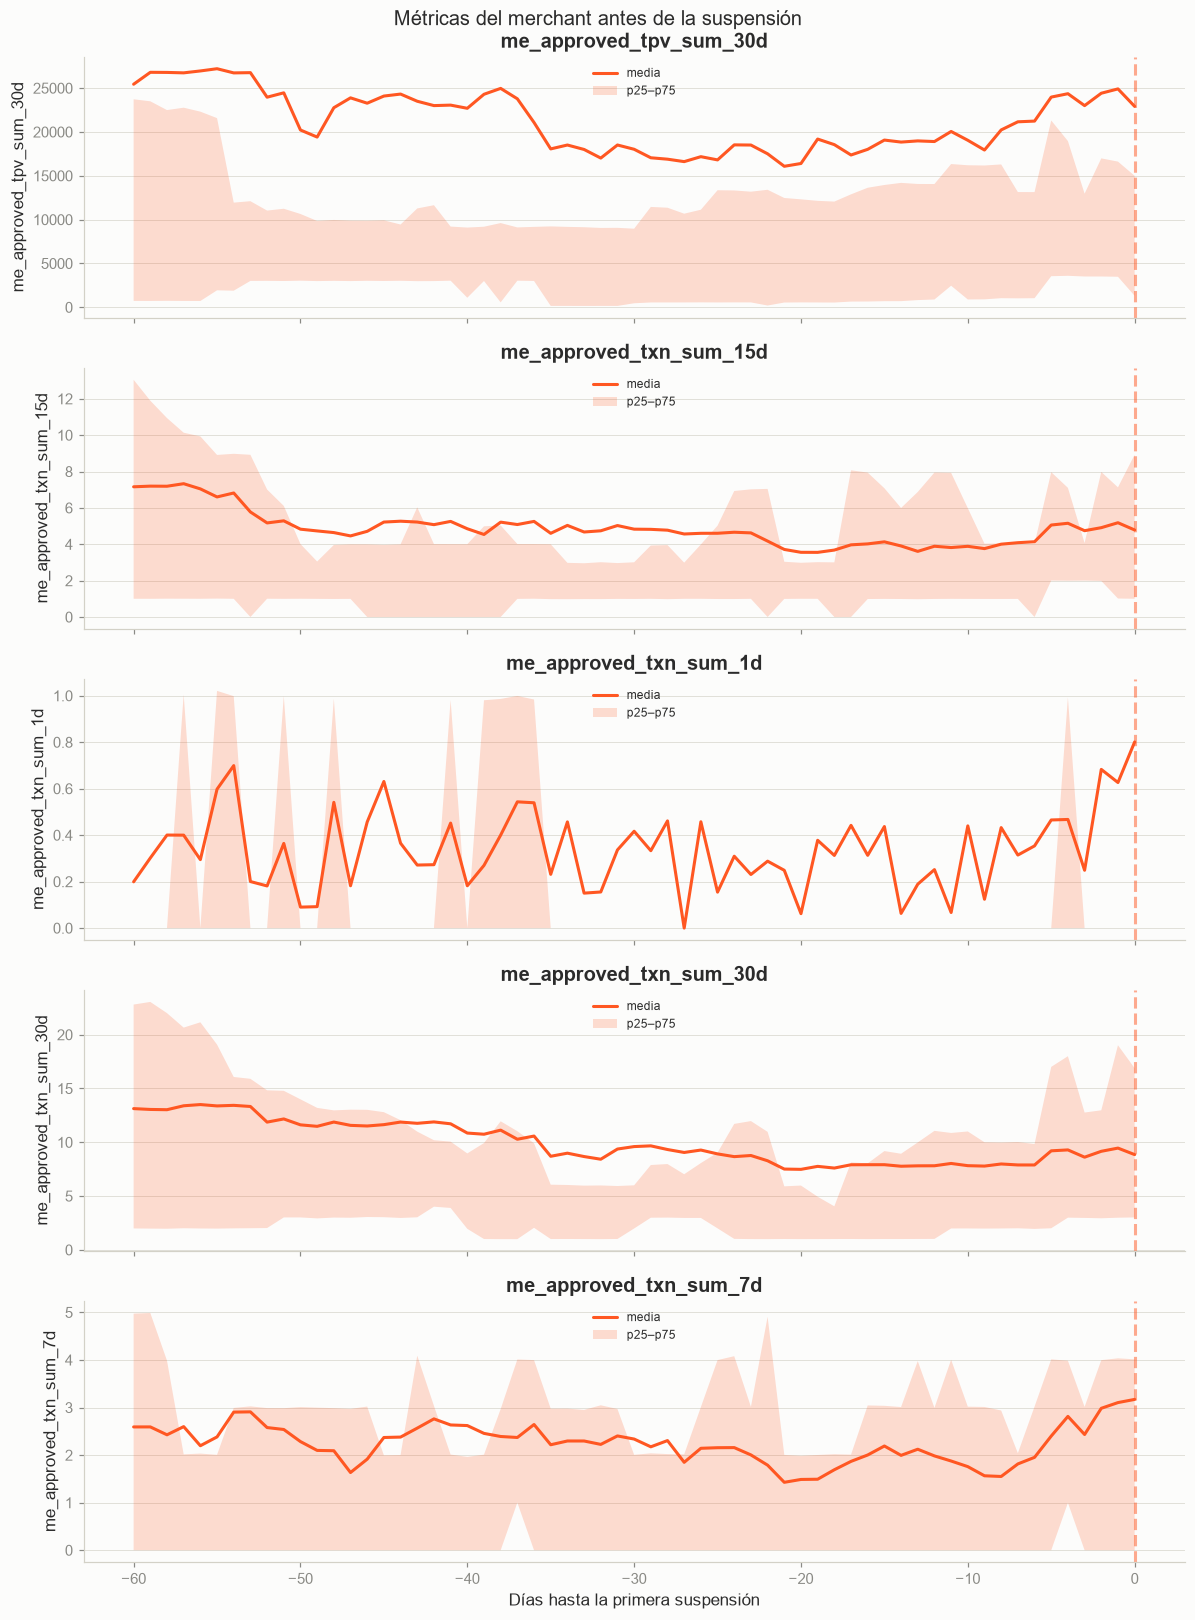

In [40]:
# Primera suspensión observada por merchant
first_susp = (
    lf_panel
    .filter(pl.col("is_suspended") == True)
    .group_by("merchant_id")
    .agg(pl.col("observation_date").min().alias("first_susp_date"))
)

# Ventana de 60 días previos a la primera suspensión
panel_evt = (
    lf_panel
    .join(first_susp, on="merchant_id", how="inner")
    .with_columns(
        (
            pl.col("observation_date").cast(pl.Date)
            - pl.col("first_susp_date").cast(pl.Date)
        )
        .dt.total_days()
        .alias("days_to_suspension")
    )
    .filter(pl.col("days_to_suspension").is_between(-60, 0))
)

metrics = [
    c for c in panel_evt.collect_schema().names()
    if any(x in c for x in ("approval_rate", "txn_sum", "tpv_sum"))
    and "network" not in c
    and not c.startswith("ind_")
][:5]

# Agregar antes de pasar a pandas
plot_df = (
    panel_evt
    .group_by("days_to_suspension")
    .agg([
        pl.col(m).mean().alias(f"{m}_mean")
        for m in metrics
    ] + [
        pl.col(m).quantile(0.25).alias(f"{m}_p25")
        for m in metrics
    ] + [
        pl.col(m).quantile(0.75).alias(f"{m}_p75")
        for m in metrics
    ])
    .sort("days_to_suspension")
    .collect(engine="streaming")
    .to_pandas()
)

print(
    panel_evt.select(
        pl.len().alias("filas"),
        pl.col("merchant_id").n_unique().alias("merchants"),
    ).collect()
)

fig, axes = plt.subplots(
    len(metrics), 1,
    figsize=(11, 3 * len(metrics)),
    sharex=True,
    squeeze=False,
)

x = plot_df["days_to_suspension"]

for ax, metric in zip(axes.flat, metrics):
    ax.plot(x, plot_df[f"{metric}_mean"], label="media")
    ax.fill_between(
        x,
        plot_df[f"{metric}_p25"],
        plot_df[f"{metric}_p75"],
        alpha=0.2,
        label="p25–p75",
    )
    ax.axvline(0, linestyle="--", alpha=0.5)
    ax.set(title=metric, ylabel=metric)
    ax.legend(fontsize=8)

axes[-1, 0].set_xlabel("Días hasta la primera suspensión")
plt.suptitle("Métricas del merchant antes de la suspensión")
plt.tight_layout()
plt.show()

Observamos algunas diferencias entre los comportamientos de pagos aprobados previamente en comparativa con los merchants no suspendidos. Esto nos puede dar un indicio del cambio de comportamiento entre el merchant fraudulento y el no fraudulento

## Null rate

In [41]:
# % nulos por columna 
null_rates = (
    lf_panel.select(pl.all().is_null().mean())
    .collect()
    .transpose(include_header=True, header_name="column", column_names=["null_rate"])
    .sort("null_rate", descending=True)
)

for label, expr in [
    (">50% nulos",  pl.col("null_rate") > 0.5),
    ("5-50% nulos", pl.col("null_rate").is_between(0.05, 0.5)),
    ("≤5% nulos",   pl.col("null_rate") <= 0.05),
]:
    sub = null_rates.filter(expr)
    print(f"\n=== {label} ({len(sub)} cols) ===")
    print(sub.head(30))


=== >50% nulos (14 cols) ===
shape: (14, 2)
┌─────────────────────────────────┬───────────┐
│ column                          ┆ null_rate │
│ ---                             ┆ ---       │
│ str                             ┆ f64       │
╞═════════════════════════════════╪═══════════╡
│ config_segment                  ┆ 1.0       │
│ is_veto_vip0                    ┆ 0.99184   │
│ vip0_segment                    ┆ 0.99184   │
│ is_veto_config                  ┆ 0.99184   │
│ is_portfolio_managed            ┆ 0.983985  │
│ …                               ┆ …         │
│ me_network_avg_tpv_dispute_rat… ┆ 0.750116  │
│ me_network_avg_tpv_approval_ra… ┆ 0.749491  │
│ me_network_size                 ┆ 0.749423  │
│ me_suspended_merchants_in_netw… ┆ 0.749423  │
│ me_suspended_merchants_in_netw… ┆ 0.749423  │
└─────────────────────────────────┴───────────┘

=== 5-50% nulos (50 cols) ===
shape: (30, 2)
┌─────────────────────────────────┬───────────┐
│ column                          ┆ null_rate

Vale la pena segmentar las columnas con nulos y saber como tratarlas.

* Algunas columnas son metricas acumulativas del pasado del merchant, por lo que es esperable que algunos registros no tengan informacion suficiente para tener valores
* Otras son segmentos operacionales que no seran tan necesarios para las predicciones, ocmo closed_won, porfolio_managed, vip0 si bien dan informacion sobre el merchant esta probablemente este reflejada en otros campos



shape: (1, 9)
┌──────────┬────────────┬────────────┬──────────┬───┬───────┬────────────┬────────────┬────────────┐
│ min      ┆ mean       ┆ median     ┆ max      ┆ … ┆ ceros ┆ duplicados ┆ approved_r ┆ fraud_rate │
│ ---      ┆ ---        ┆ ---        ┆ ---      ┆   ┆ ---   ┆ ---        ┆ ate        ┆ ---        │
│ f64      ┆ f64        ┆ f64        ┆ f64      ┆   ┆ u32   ┆ u32        ┆ ---        ┆ f64        │
│          ┆            ┆            ┆          ┆   ┆       ┆            ┆ f64        ┆            │
╞══════════╪════════════╪════════════╪══════════╪═══╪═══════╪════════════╪════════════╪════════════╡
│ 0.009653 ┆ 518.492449 ┆ 146.902421 ┆ 1.6556e6 ┆ … ┆ 0     ┆ 0          ┆ 0.934393   ┆ 0.000367   │
└──────────┴────────────┴────────────┴──────────┴───┴───────┴────────────┴────────────┴────────────┘
shape: (2, 5)
┌──────────────┬─────────┬───────────────┬────────────┬──────────┐
│ payment_type ┆ n       ┆ approved_rate ┆ fraud_rate ┆ tpv      │
│ ---          ┆ ---     ┆ ---

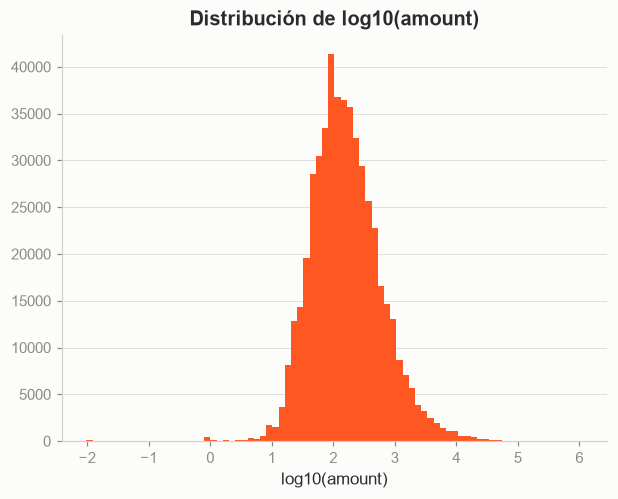

In [42]:
summary = lf_txn.select(
    pl.col("amount").min().alias("min"),
    pl.col("amount").mean().alias("mean"),
    pl.col("amount").median().alias("median"),
    pl.col("amount").max().alias("max"),
    (pl.col("amount") < 0).sum().alias("negativos"),
    (pl.col("amount") == 0).sum().alias("ceros"),
    pl.col("transaction_id").is_duplicated().sum().alias("duplicados"),
    pl.col("approved").mean().alias("approved_rate"),
    pl.col("is_fraud").mean().alias("fraud_rate"),
).collect()

rates = (
    lf_txn.group_by("payment_type")
    .agg(
        pl.len().alias("n"),
        pl.col("approved").mean().alias("approved_rate"),
        pl.col("is_fraud").mean().alias("fraud_rate"),
        pl.col("amount").sum().alias("tpv"),
    )
    .sort("n", descending=True)
    .collect()
)

amounts = (
    lf_txn
    .filter(
        (pl.col("amount") > 0)
        & (pl.col("transaction_id").hash(seed=1) % 100 < 10)
    )
    .select(pl.col("amount").log10())
    .limit(500_000)
    .collect(engine="streaming")
    .to_series()
    .to_numpy()
)

print(summary)
print(rates)

plt.hist(amounts, bins=80)
plt.title("Distribución de log10(amount)")
plt.xlabel("log10(amount)")
plt.show()

La celda superior nos permite observar el comportamiento de los montos procesados
* Su distribucion
* Su agrupacion (CNP, CP, Fraude, no fraude)
* Validacion de nulos o duplicados

In [43]:
print("crosstab approved × is_fraud:")
print(lf_txn.group_by(["approved", "is_fraud"]).agg(pl.len().alias("n")).sort(["approved", "is_fraud"]).collect())

fraud_rejected = lf_txn.filter((pl.col("is_fraud") == 1) & (pl.col("approved") == 0)).select(pl.len()).collect().item()
fraud_total    = lf_txn.filter(pl.col("is_fraud") == 1).select(pl.len()).collect().item()
print(f"\nis_fraud==1 & approved==0: {fraud_rejected:,}  ({fraud_rejected/max(fraud_total,1):.2%} del total fraude)")

crosstab approved × is_fraud:
shape: (4, 3)
┌──────────┬──────────┬─────────┐
│ approved ┆ is_fraud ┆ n       │
│ ---      ┆ ---      ┆ ---     │
│ i32      ┆ i32      ┆ u32     │
╞══════════╪══════════╪═════════╡
│ 0        ┆ 0        ┆ 464355  │
│ 0        ┆ 1        ┆ 138     │
│ 1        ┆ 0        ┆ 6612994 │
│ 1        ┆ 1        ┆ 2462    │
└──────────┴──────────┴─────────┘

is_fraud==1 & approved==0: 138  (5.31% del total fraude)


## Evaluacion de leakeage

In [44]:
# industry_mcc vs. me_industry_mcc
both = lf_panel.select(["industry_mcc", "me_industry_mcc"]).drop_nulls().collect()
n_diff = (both["industry_mcc"] != both["me_industry_mcc"]).sum()
print(f"filas con divergencia: {n_diff:,} / {len(both):,}")
if n_diff > 0:
    print(both.filter(pl.col("industry_mcc") != pl.col("me_industry_mcc")).head(10))
else:
    print("→ idénticas donde ambas son no-nulas; una es redundante.")

filas con divergencia: 10,728 / 4,912,747
shape: (10, 2)
┌──────────────┬─────────────────┐
│ industry_mcc ┆ me_industry_mcc │
│ ---          ┆ ---             │
│ i64          ┆ i64             │
╞══════════════╪═════════════════╡
│ 5046         ┆ 5499            │
│ 5046         ┆ 5499            │
│ 5046         ┆ 5499            │
│ 5046         ┆ 5499            │
│ 5046         ┆ 5812            │
│ 5046         ┆ 5812            │
│ 5046         ┆ 5499            │
│ 5046         ┆ 5499            │
│ 5651         ┆ 5046            │
│ 5651         ┆ 5046            │
└──────────────┴─────────────────┘


Ubicamos columnas redundantes entre si

In [45]:
leakage_patterns = {
    # Consecuencias del fraude, no antecedentes: un chargeback/disputa existe
    # PORQUE hubo fraude. Son las de mayor correlación con el target.
    "chargeback":           "consecuencia del fraude, no antecedente",
    "dispute":              "consecuencia del fraude, no antecedente",
    "claims":               "reclamo posterior al fraude",
    # Decisiones internas de riesgo
    "suspended_merchants_in_network": "señal de red que puede reflejar la propia decisión de suspender",
    "is_veto":              "decisión interna de riesgo",
    "is_portfolio_managed": "asignación operativa correlada con seguimiento de riesgo",
    "is_closed_won_ever":   "ciclo de vida comercial post-onboarding",
    "config_segment":       "clasificación operativa",
    "vip0_segment":         "clasificación operativa",
}

all_cols = list(lf_panel.collect_schema().names())
corr_lookup = dict(zip(corr_df["feature"].to_list(), corr_df["abs_corr"].to_list()))
flagged = [
    {"column": c, "pattern": pat, "reason": reason, "abs_corr": corr_lookup.get(c)}
    for pat, reason in leakage_patterns.items()
    for c in all_cols if pat in c
]
print("Features con patrón de leakage, ordenadas por correlación con fraud_rate_tpv:")
print(pl.DataFrame(flagged).sort("abs_corr", descending=True, nulls_last=True))

Features con patrón de leakage, ordenadas por correlación con fraud_rate_tpv:
shape: (14, 4)
┌────────────────────────────────┬──────────────────────┬───────────────────────────────┬──────────┐
│ column                         ┆ pattern              ┆ reason                        ┆ abs_corr │
│ ---                            ┆ ---                  ┆ ---                           ┆ ---      │
│ str                            ┆ str                  ┆ str                           ┆ f64      │
╞════════════════════════════════╪══════════════════════╪═══════════════════════════════╪══════════╡
│ me_lifetime_chargeback_tpv     ┆ chargeback           ┆ consecuencia del fraude, no   ┆ 0.531361 │
│                                ┆                      ┆ an…                           ┆          │
│ ratio_claims_tpv_180d          ┆ claims               ┆ reclamo posterior al fraude   ┆ 0.436514 │
│ me_lifetime_dispute_tpv        ┆ dispute              ┆ consecuencia del fraude, no   ┆ 0.367193 

pares con |corr| > 0.9: 49
shape: (49, 3)
┌─────────────────────────────────┬─────────────────────────┬──────────┐
│ feature_a                       ┆ feature_b               ┆ abs_corr │
│ ---                             ┆ ---                     ┆ ---      │
│ str                             ┆ str                     ┆ f64      │
╞═════════════════════════════════╪═════════════════════════╪══════════╡
│ me_txn_approval_rate_1d         ┆ me_tpv_approval_rate_1d ┆ 0.9994   │
│ me_attempted_txn_sum_30d        ┆ me_approved_txn_sum_30d ┆ 0.9993   │
│ me_attempted_txn_sum_15d        ┆ me_approved_txn_sum_15d ┆ 0.9992   │
│ me_suspended_merchants_in_netw… ┆ me_network_size         ┆ 0.9992   │
│ me_attempted_txn_sum_7d         ┆ me_approved_txn_sum_7d  ┆ 0.999    │
│ …                               ┆ …                       ┆ …        │
│ me_attempted_txn_sum_1d         ┆ me_approved_txn_sum_30d ┆ 0.9139   │
│ me_approved_txn_sum_15d         ┆ approved_txns_90d       ┆ 0.9117   │
│ me_atte

C:\Users\lautaro.paniagua_roc\AppData\Local\Temp\ipykernel_14844\1681972398.py:13: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  print(pl.DataFrame(pairs, schema=["feature_a", "feature_b", "abs_corr"]).sort("abs_corr", descending=True))


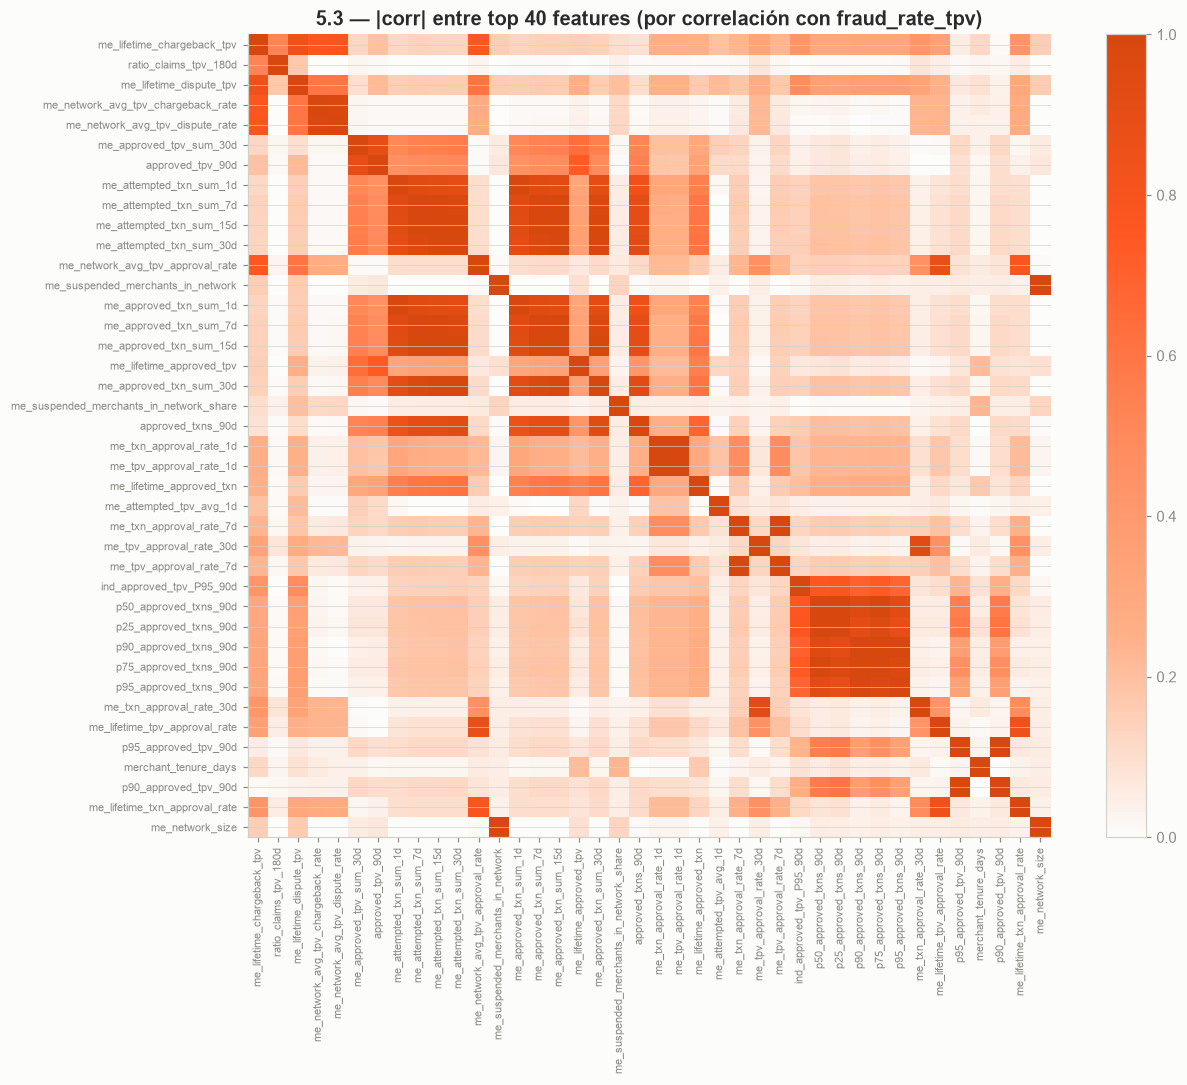

In [46]:
# pares de features con |corr| > 0.9 (top 40 por relevancia)
top_feats = [f for f in corr_df.head(40)["feature"].to_list() if f in panel_sample.columns]
corr_mat  = panel_sample.select(top_feats).to_pandas().corr().abs()

pairs = [
    (corr_mat.columns[i], corr_mat.columns[j], round(corr_mat.iloc[i, j], 4))
    for i in range(len(corr_mat))
    for j in range(i + 1, len(corr_mat))
    if corr_mat.iloc[i, j] > 0.9
]
print(f"pares con |corr| > 0.9: {len(pairs)}")
if pairs:
    print(pl.DataFrame(pairs, schema=["feature_a", "feature_b", "abs_corr"]).sort("abs_corr", descending=True))

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_mat.values,cmap=cs.CLIP_CMAP, vmin=0, vmax=1)
ax.set_xticks(range(len(top_feats))); ax.set_yticks(range(len(top_feats)))
ax.set_xticklabels(top_feats, rotation=90, fontsize=7)
ax.set_yticklabels(top_feats, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.04)
ax.set_title("5.3 — |corr| entre top 40 features (por correlación con fraud_rate_tpv)")
plt.tight_layout(); plt.show()

## Analisis descriptivo comportamiento de suspendidos

In [47]:
# 6.1 — métricas de red: suspendidos vs. no suspendidos (última observación por merchant)
net_cols = [c for c in lf_panel.schema if "network" in c or "suspended_merchants_in" in c]
net_last = (
    lf_panel.select(["merchant_id", "observation_date"] + net_cols)
    .sort("observation_date")
    .group_by("merchant_id")
    .agg([pl.col(c).last() for c in net_cols])
    .with_columns(pl.col("merchant_id").is_in(susp_id_set).alias("ever_suspended"))
    .collect()
)

print("Métricas de red — media por grupo:")
print(net_last.group_by("ever_suspended").agg([pl.col(c).mean().round(4) for c in net_cols]).sort("ever_suspended"))

C:\Users\lautaro.paniagua_roc\AppData\Local\Temp\ipykernel_14844\1570230252.py:2: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  net_cols = [c for c in lf_panel.schema if "network" in c or "suspended_merchants_in" in c]


Métricas de red — media por grupo:
shape: (2, 7)
┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ ever_suspend ┆ me_network_ ┆ me_network_ ┆ me_network_ ┆ me_network_ ┆ me_suspende ┆ me_suspende │
│ ed           ┆ avg_tpv_app ┆ avg_tpv_cha ┆ avg_tpv_dis ┆ size        ┆ d_merchants ┆ d_merchants │
│ ---          ┆ roval_ra…   ┆ rgeback_…   ┆ pute_rat…   ┆ ---         ┆ _in_netw…   ┆ _in_netw…   │
│ bool         ┆ ---         ┆ ---         ┆ ---         ┆ f64         ┆ ---         ┆ ---         │
│              ┆ f64         ┆ f64         ┆ f64         ┆             ┆ f64         ┆ f64         │
╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ false        ┆ 0.8128      ┆ 0.0016      ┆ 0.0019      ┆ 166.5505    ┆ 59.6101     ┆ 0.0573      │
│ true         ┆ 0.7318      ┆ 0.0003      ┆ 0.0006      ┆ 12.1429     ┆ 1.5714      ┆ 0.1726      │
└──────────────┴─────────────┴────────────

CP / CNP por grupo:
shape: (4, 8)
┌────────────┬────────────┬─────────┬────────────┬────────────┬────────────┬───────────┬───────────┐
│ ever_suspe ┆ payment_ty ┆ n_txn   ┆ tpv        ┆ approval_r ┆ fraud_rate ┆ share_txn ┆ share_tpv │
│ nded       ┆ pe         ┆ ---     ┆ ---        ┆ ate        ┆ ---        ┆ ---       ┆ ---       │
│ ---        ┆ ---        ┆ u32     ┆ f64        ┆ ---        ┆ f64        ┆ f64       ┆ f64       │
│ bool       ┆ str        ┆         ┆            ┆ f64        ┆            ┆           ┆           │
╞════════════╪════════════╪═════════╪════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ false      ┆ CNP        ┆ 92304   ┆ 4.4363e8   ┆ 0.667425   ┆ 0.004106   ┆ 0.013044  ┆ 0.12112   │
│ false      ┆ CP         ┆ 6983794 ┆ 3.2191e9   ┆ 0.938003   ┆ 0.000281   ┆ 0.986956  ┆ 0.87888   │
│ true       ┆ CNP        ┆ 112     ┆ 415989.017 ┆ 0.669643   ┆ 0.0        ┆ 0.029083  ┆ 0.050941  │
│            ┆            ┆         ┆ 445        ┆       

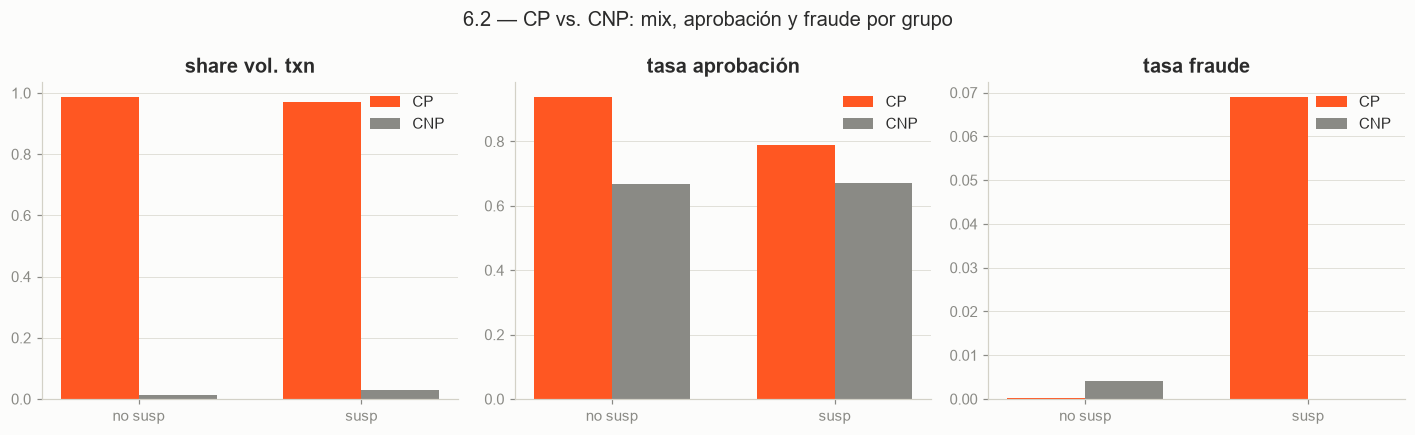

In [48]:
pt = (
    lf_txn.with_columns(pl.col("merchant_id").is_in(susp_id_set).alias("ever_suspended"))
    .group_by(["ever_suspended", "payment_type"]).agg(
        pl.len().alias("n_txn"),
        pl.col("amount").sum().alias("tpv"),
        pl.col("approved").mean().alias("approval_rate"),
        pl.col("is_fraud").mean().alias("fraud_rate"),
    )
    .with_columns(
        (pl.col("n_txn") / pl.col("n_txn").sum().over("ever_suspended")).alias("share_txn"),
        (pl.col("tpv")   / pl.col("tpv").sum().over("ever_suspended")).alias("share_tpv"),
    )
    .sort(["ever_suspended", "payment_type"])
    .collect()
)
print("CP / CNP por grupo:")
print(pt)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = [("share_txn", "share vol. txn"), ("approval_rate", "tasa aprobación"), ("fraud_rate", "tasa fraude")]
groups  = pt["ever_suspended"].unique().sort().to_list()
x       = np.arange(len(groups))
width   = 0.35

for ax, (col, title) in zip(axes, metrics):
    for i, ptype in enumerate(["CP", "CNP"]):
        vals = [pt.filter((pl.col("ever_suspended") == g) & (pl.col("payment_type") == ptype))[col].to_list() for g in groups]
        vals = [v[0] if v else 0 for v in vals]
        ax.bar(x + i * width, vals, width, label=ptype)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(["no susp", "susp"])
    ax.set_title(title); ax.legend()
plt.suptitle("6.2 — CP vs. CNP: mix, aprobación y fraude por grupo")
plt.tight_layout(); plt.show()

Llamativamente al contrario de lo que hubiese supuesto, la mayoria de los fraudes en merchants suspendidos fueron realizados por metodos de tarjeta presente

canales disponibles: ['me_attempted_ecommerce_txn_sum_7d', 'me_attempted_openplatform_txn_sum_7d', 'me_attempted_pocket_txn_sum_7d', 'me_attempted_recurring_txn_sum_7d', 'me_attempted_spei_txn_sum_7d', 'me_attempted_tpv_avg_7d', 'me_attempted_txn_sum_7d']


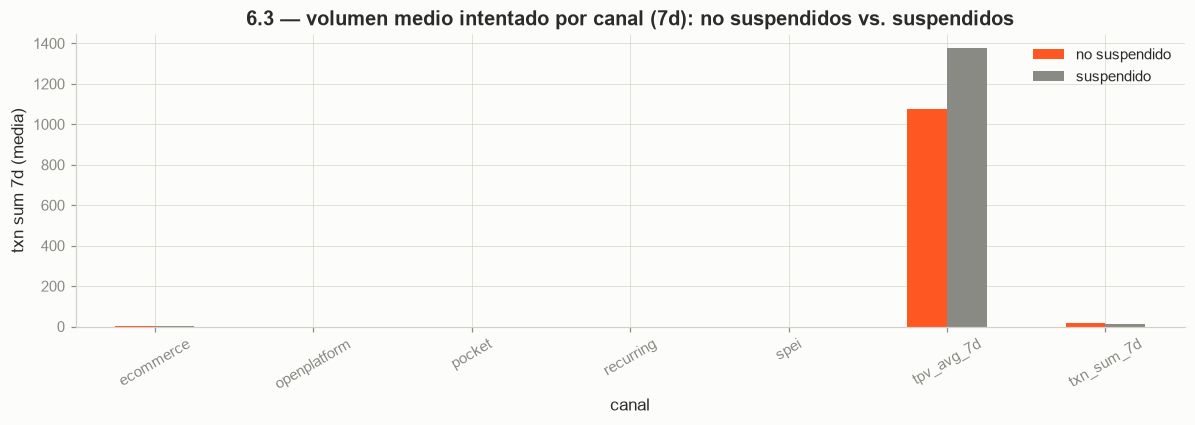

In [49]:
channel_cols = [c for c in panel_sample.columns if c.startswith("me_attempted_") and c.endswith("_7d")]
print("canales disponibles:", channel_cols)

ch = (
    panel_sample.select(["merchant_id"] + channel_cols)
    .with_columns(pl.col("merchant_id").is_in(susp_id_set).alias("ever_suspended"))
    .group_by("ever_suspended")
    .agg([pl.col(c).mean() for c in channel_cols])
    .sort("ever_suspended")
)

labels = [c.replace("me_attempted_", "").replace("_txn_sum_7d", "") for c in channel_cols]
ch_pd  = ch.to_pandas().set_index("ever_suspended")[channel_cols]
ch_pd.columns = labels

fig, ax = plt.subplots(figsize=(11, 4))
ch_pd.T.plot(kind="bar", ax=ax)
ax.set_title("6.3 — volumen medio intentado por canal (7d): no suspendidos vs. suspendidos")
ax.set_ylabel("txn sum 7d (media)"); ax.set_xlabel("canal")
ax.legend(["no suspendido", "suspendido"]); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

# Calculo de features y creacion de target
Dada la naturaleza incierta del is_suspended y la variedad de columnas disponibles para cada merchant, decidi implementar un target de fraude sintetizado por el ratio de fraude


In [50]:
INCLUDE_REJECTED_FRAUD = True

fraud_cond = pl.col("is_fraud") == 1
if not INCLUDE_REJECTED_FRAUD:
    fraud_cond = fraud_cond & (pl.col("approved") == 1)

agg = (
    lf_txn.group_by("merchant_id").agg([
        pl.col("amount").sum().alias("tpv_total"),
        pl.len().alias("n_txn_total"),
        pl.col("is_fraud").sum().alias("n_txn_fraud"),
        (pl.col("amount") * pl.col("approved")).sum().alias("tpv_approved"),
        pl.when(fraud_cond).then(pl.col("amount")).otherwise(0).sum().alias("tpv_fraud"),
    ])
    .with_columns([
        (pl.col("tpv_fraud")    / pl.col("tpv_total")).fill_nan(0).alias("fraud_rate_tpv"),
        (pl.col("n_txn_fraud")  / pl.col("n_txn_total")).fill_nan(0).alias("fraud_rate_count"),
        (pl.col("tpv_approved") / pl.col("tpv_total")).fill_nan(0).alias("approval_rate"),
        pl.col("merchant_id").is_in(susp_ids).alias("ever_suspended"),
    ])
    .collect()
)

print(f"merchants: {len(agg):,}")
print(agg.select(["tpv_total", "tpv_fraud", "n_txn_total", "fraud_rate_tpv", "approval_rate"]).describe())

merchants: 40,265
shape: (9, 6)
┌────────────┬───────────────┬──────────────┬─────────────┬────────────────┬───────────────┐
│ statistic  ┆ tpv_total     ┆ tpv_fraud    ┆ n_txn_total ┆ fraud_rate_tpv ┆ approval_rate │
│ ---        ┆ ---           ┆ ---          ┆ ---         ┆ ---            ┆ ---           │
│ str        ┆ f64           ┆ f64          ┆ f64         ┆ f64            ┆ f64           │
╞════════════╪═══════════════╪══════════════╪═════════════╪════════════════╪═══════════════╡
│ count      ┆ 40265.0       ┆ 40265.0      ┆ 40265.0     ┆ 40265.0        ┆ 40265.0       │
│ null_count ┆ 0.0           ┆ 0.0          ┆ 0.0         ┆ 0.0            ┆ 0.0           │
│ mean       ┆ 91168.511078  ┆ 202.892021   ┆ 175.833826  ┆ 0.001356       ┆ 0.862915      │
│ std        ┆ 917503.458003 ┆ 5636.253046  ┆ 947.278609  ┆ 0.023911       ┆ 0.233873      │
│ min        ┆ 0.009801      ┆ 0.0          ┆ 1.0         ┆ 0.0            ┆ 0.0           │
│ 25%        ┆ 4269.018662   ┆ 0.0    

shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 40265.0    │
│ null_count ┆ 0.0        │
│ mean       ┆ 175.833826 │
│ std        ┆ 947.278609 │
│ min        ┆ 1.0        │
│ 25%        ┆ 4.0        │
│ 50%        ┆ 14.0       │
│ 75%        ┆ 73.0       │
│ max        ┆ 116931.0   │
└────────────┴────────────┘


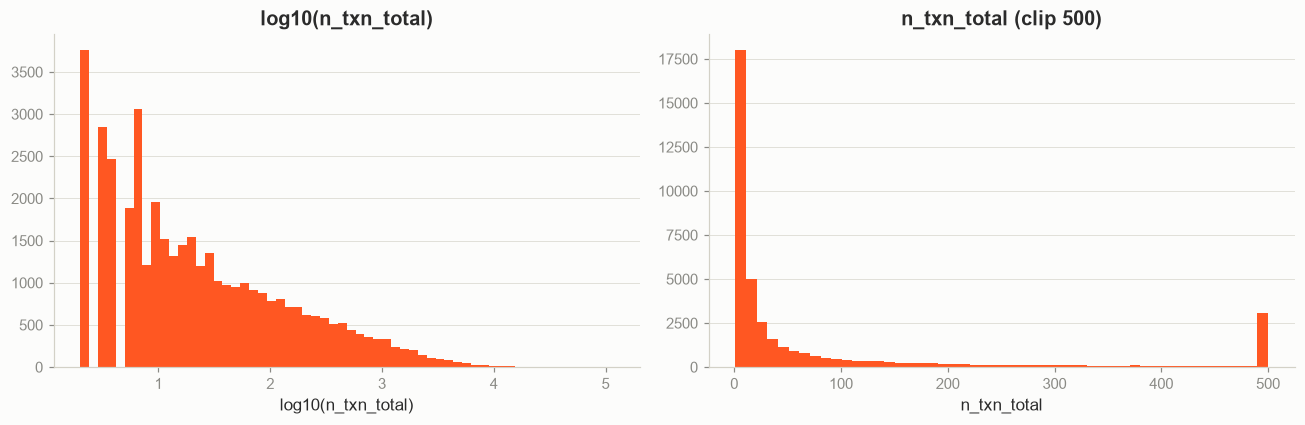

In [51]:
print(agg["n_txn_total"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log10(agg["n_txn_total"].to_numpy() + 1), bins=60)
axes[0].set_title("log10(n_txn_total)"); axes[0].set_xlabel("log10(n_txn_total)")

axes[1].hist(agg["n_txn_total"].clip(upper_bound=500).to_numpy(), bins=50)
axes[1].set_title("n_txn_total (clip 500)"); axes[1].set_xlabel("n_txn_total")
plt.tight_layout(); plt.show()

Volatilidad de fraud_rate_tpv por bin de n_txn_total:
shape: (7, 5)
┌─────────┬─────────────┬──────────┬──────────┬─────┐
│ bin     ┆ n_merchants ┆ media    ┆ std      ┆ iqr │
│ ---     ┆ ---         ┆ ---      ┆ ---      ┆ --- │
│ enum    ┆ u32         ┆ f64      ┆ f64      ┆ f64 │
╞═════════╪═════════════╪══════════╪══════════╪═════╡
│ ≤10     ┆ 17989       ┆ 0.001526 ┆ 0.030398 ┆ 0.0 │
│ 11-30   ┆ 7565        ┆ 0.00213  ┆ 0.025971 ┆ 0.0 │
│ 31-50   ┆ 2744        ┆ 0.000862 ┆ 0.010384 ┆ 0.0 │
│ 51-100  ┆ 3345        ┆ 0.000872 ┆ 0.010494 ┆ 0.0 │
│ 101-300 ┆ 4127        ┆ 0.00102  ┆ 0.012003 ┆ 0.0 │
│ 301-500 ┆ 1462        ┆ 0.000419 ┆ 0.002664 ┆ 0.0 │
│ 500+    ┆ 3033        ┆ 0.000307 ┆ 0.00231  ┆ 0.0 │
└─────────┴─────────────┴──────────┴──────────┴─────┘


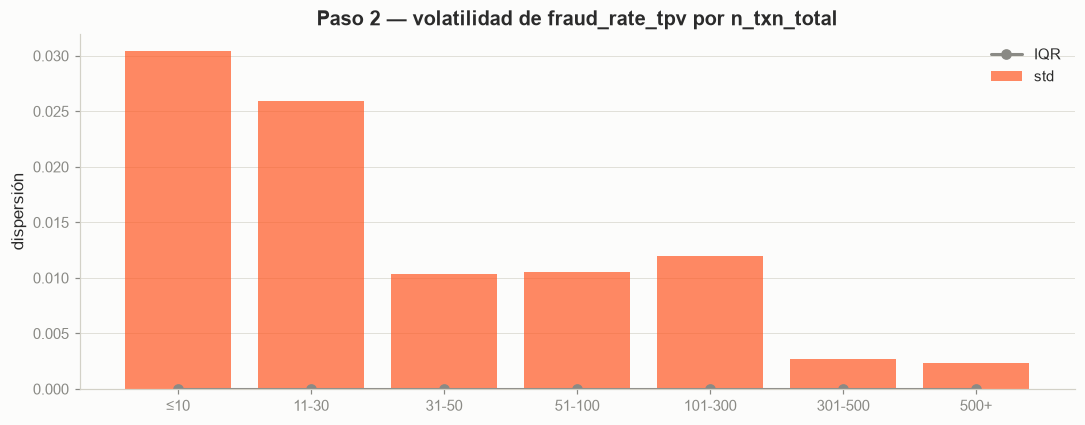

In [52]:
BIN_BREAKS = [10, 30, 50, 100, 300, 500]
BIN_LABELS = ["≤10", "11-30", "31-50", "51-100", "101-300", "301-500", "500+"]

vol = (
    agg.with_columns(
        pl.col("n_txn_total").cut(BIN_BREAKS, labels=BIN_LABELS).alias("bin")
    )
    .group_by("bin").agg([
        pl.len().alias("n_merchants"),
        pl.col("fraud_rate_tpv").mean().alias("media"),
        pl.col("fraud_rate_tpv").std().alias("std"),
        (pl.col("fraud_rate_tpv").quantile(0.75) - pl.col("fraud_rate_tpv").quantile(0.25)).alias("iqr"),
    ])
    .sort("bin")
)
print("Volatilidad de fraud_rate_tpv por bin de n_txn_total:")
print(vol)

x = range(len(vol))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x, vol["std"].to_numpy(), alpha=0.7, label="std")
ax.plot(x, vol["iqr"].to_numpy(), "o-", color="C1", lw=2, label="IQR")
ax.set_xticks(x); ax.set_xticklabels(BIN_LABELS)
ax.set_title("Paso 2 — volatilidad de fraud_rate_tpv por n_txn_total")
ax.set_ylabel("dispersión"); ax.legend()
plt.tight_layout(); plt.show()

In [53]:
tpv_all = agg["tpv_total"].sum()
for floor in [10, 30, 50]:
    incl = agg.filter(pl.col("n_txn_total") >= floor)
    excl = agg.filter(pl.col("n_txn_total") <  floor)
    print(f"piso >= {floor:>3d}:  quedan {len(incl):,} merchants ({len(incl)/len(agg):.1%})  |  "
          f"excluidos: {len(excl):,} = {excl['tpv_total'].sum()/tpv_all:.2%} del TPV")

piso >=  10:  quedan 23,083 merchants (57.3%)  |  excluidos: 17,182 = 6.29% del TPV
piso >=  30:  quedan 14,885 merchants (37.0%)  |  excluidos: 25,380 = 16.39% del TPV
piso >=  50:  quedan 12,056 merchants (29.9%)  |  excluidos: 28,209 = 22.22% del TPV


El piso de actividad mayor cobertura que excluye el menor porcentaje de PTV es el 10, por eso selecciono este para la creacion del target

In [54]:
ACTIVITY_FLOOR = 10

agg_clean = agg.filter(pl.col("n_txn_total") >= ACTIVITY_FLOOR)
rates = agg_clean["fraud_rate_tpv"].to_numpy()

print(f"merchants con n >= {ACTIVITY_FLOOR}: {len(agg_clean):,}")
print(f"fraude > 0:  {(rates > 0).sum():,}")
print(f"fraude == 0: {(rates == 0).sum():,}")

merchants con n >= 10: 23,083
fraude > 0:  1,012
fraude == 0: 22,071


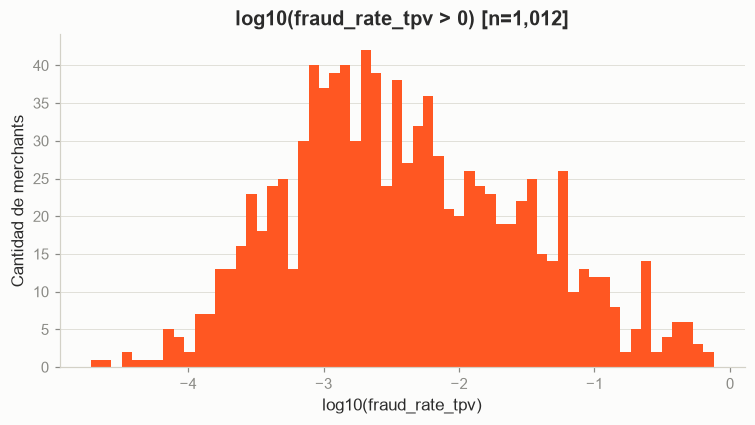

In [55]:
pos = rates[rates > 0]

plt.figure(figsize=(7, 4))
plt.hist(np.log10(pos + 1e-6), bins=60)

plt.title(f"log10(fraud_rate_tpv > 0) [n={len(pos):,}]")
plt.xlabel("log10(fraud_rate_tpv)")
plt.ylabel("Cantidad de merchants")

plt.tight_layout()
plt.show()

In [56]:
tpv_clean = agg_clean["tpv_total"].sum()
n_total   = len(agg_clean)

# Desde P90: por debajo el umbral da 0 y todas las filas son el mismo filtro
# (el 95.6% de los merchants tiene fraud_rate_tpv == 0).
rows = []
for p in [90, 95, 96, 97, 98, 99, 99.5]:
    thr = float(np.percentile(rates, p))
    pos = agg_clean.filter(pl.col("fraud_rate_tpv") > thr)
    rows.append({"percentil": f"P{p}", "umbral": round(thr, 6),
                 "n_positivos": len(pos), "pct_merchants": f"{len(pos)/n_total:.2%}",
                 "pct_tpv": f"{pos['tpv_total'].sum()/tpv_clean:.2%}"})
print(pl.DataFrame(rows))

shape: (7, 5)
┌───────────┬──────────┬─────────────┬───────────────┬─────────┐
│ percentil ┆ umbral   ┆ n_positivos ┆ pct_merchants ┆ pct_tpv │
│ ---       ┆ ---      ┆ ---         ┆ ---           ┆ ---     │
│ str       ┆ f64      ┆ i64         ┆ str           ┆ str     │
╞═══════════╪══════════╪═════════════╪═══════════════╪═════════╡
│ P90       ┆ 0.0      ┆ 1012        ┆ 4.38%         ┆ 25.13%  │
│ P95       ┆ 0.0      ┆ 1012        ┆ 4.38%         ┆ 25.13%  │
│ P96       ┆ 0.000302 ┆ 924         ┆ 4.00%         ┆ 16.82%  │
│ P97       ┆ 0.001299 ┆ 693         ┆ 3.00%         ┆ 9.92%   │
│ P98       ┆ 0.004134 ┆ 462         ┆ 2.00%         ┆ 5.59%   │
│ P99       ┆ 0.020822 ┆ 231         ┆ 1.00%         ┆ 2.10%   │
│ P99.5     ┆ 0.056798 ┆ 116         ┆ 0.50%         ┆ 1.02%   │
└───────────┴──────────┴─────────────┴───────────────┴─────────┘


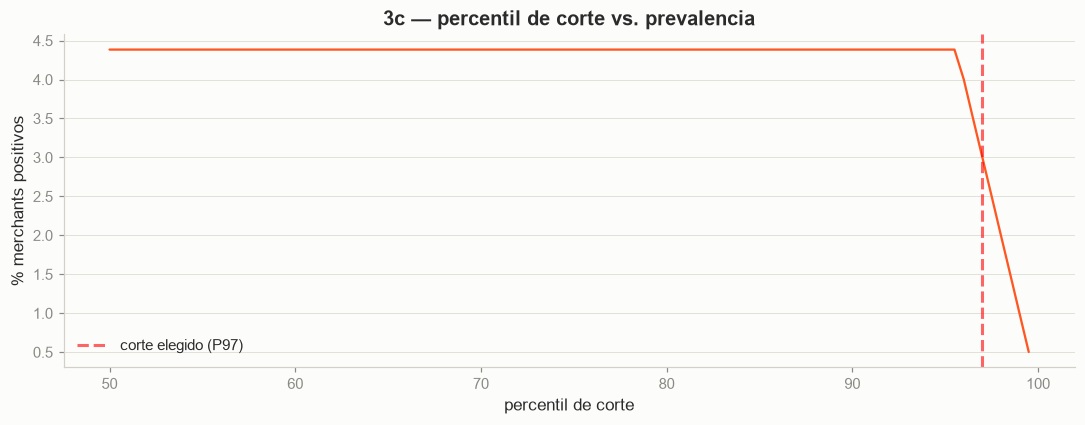

In [57]:
pcts      = np.arange(50, 100, 0.5)
thresholds = np.percentile(rates, pcts)
pos_share  = [(rates > t).mean() * 100 for t in thresholds]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pcts, pos_share, lw=1.5)
ax.axvline(97, color="red", ls="--", alpha=0.6, label="corte elegido (P97)")
ax.set_xlabel("percentil de corte"); ax.set_ylabel("% merchants positivos")
ax.set_title("3c — percentil de corte vs. prevalencia")
ax.legend(); plt.tight_layout(); plt.show()

## Validacion del target con merchants suspendidos

Paso importante y aca entra el analisis descriptivo que nos proporciona la baja proporcion de merchats suspendidos.

Para evaluar si realmente nuestro target captura correctamente el riesgo, los merchants suspendidos deberian de caer en percentiles altos del  grupo 

In [58]:
susp_agg  = agg.filter(pl.col("merchant_id").is_in(susp_ids))
ref_rates = agg_clean["fraud_rate_tpv"].to_numpy()

n_ref = len(ref_rates)
n_zero_ref = (ref_rates == 0.0).sum()
pct_zero_ref = n_zero_ref / n_ref * 100

pct_ranks = [(ref_rates <= r).mean() * 100 for r in susp_agg["fraud_rate_tpv"].to_list()]

result = (
    susp_agg
    .with_columns([
        pl.Series("pct_rank", pct_ranks).round(1),
        (pl.col("n_txn_total") >= ACTIVITY_FLOOR).alias("en_grupo_clean"),
        (pl.col("fraud_rate_tpv") == 0.0).alias("tiene_fraude_cero"),
    ])
    .sort("pct_rank", descending=True)
)

print(f"% de agg_clean con fraud_rate_tpv == 0.0: {pct_zero_ref:.1f}%")
print(f"(cualquier percentil <= {pct_zero_ref:.1f} para un merchant con rate=0.0 es un artefacto del empate, no señal real)")
print()
print(result.select(["merchant_id", "n_txn_total", "fraud_rate_tpv", "fraud_rate_count",
                      "pct_rank", "en_grupo_clean", "tiene_fraude_cero"]))

% de agg_clean con fraud_rate_tpv == 0.0: 95.6%
(cualquier percentil <= 95.6 para un merchant con rate=0.0 es un artefacto del empate, no señal real)

shape: (26, 7)
┌──────────────┬─────────────┬──────────────┬──────────────┬──────────┬──────────────┬─────────────┐
│ merchant_id  ┆ n_txn_total ┆ fraud_rate_t ┆ fraud_rate_c ┆ pct_rank ┆ en_grupo_cle ┆ tiene_fraud │
│ ---          ┆ ---         ┆ pv           ┆ ount         ┆ ---      ┆ an           ┆ e_cero      │
│ str          ┆ u32         ┆ ---          ┆ ---          ┆ f64      ┆ ---          ┆ ---         │
│              ┆             ┆ f64          ┆ f64          ┆          ┆ bool         ┆ bool        │
╞══════════════╪═════════════╪══════════════╪══════════════╪══════════╪══════════════╪═════════════╡
│ M46B66AE0E30 ┆ 2391        ┆ 0.10124      ┆ 0.107068     ┆ 99.7     ┆ true         ┆ false       │
│ 9595B        ┆             ┆              ┆              ┆          ┆              ┆             │
│ MA52FE20E571 ┆ 57       

In [59]:
n_con_fraude = susp_agg.filter(pl.col("fraud_rate_tpv") > 0.0).height
n_total_susp = susp_agg.height
print(f"{n_con_fraude} de {n_total_susp} suspendidos tienen fraud_rate_tpv > 0 ({n_con_fraude/n_total_susp:.1%})")

3 de 26 suspendidos tienen fraud_rate_tpv > 0 (11.5%)


Hipotesis de esto

- Ventana temporal desalineada entre panel de merchants y txn
- Suspensión por motivo no-transaccional

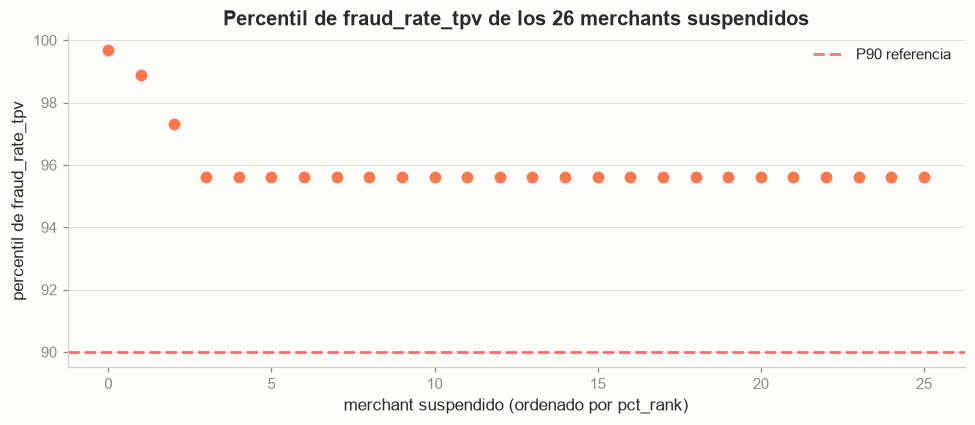


mediana pct_rank (suspendidos): 95.6
% suspendidos sobre P90:        100.0%


In [60]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(range(len(result)), result["pct_rank"].to_numpy(), s=60, alpha=0.8)
ax.axhline(90, color="red", ls="--", alpha=0.5, label="P90 referencia")
ax.set_xlabel("merchant suspendido (ordenado por pct_rank)")
ax.set_ylabel("percentil de fraud_rate_tpv")
ax.set_title("Percentil de fraud_rate_tpv de los 26 merchants suspendidos")
ax.legend(); plt.tight_layout(); plt.show()

print(f"\nmediana pct_rank (suspendidos): {result['pct_rank'].median():.1f}")
print(f"% suspendidos sobre P90:        {(result['pct_rank'] > 90).mean():.1%}")

In [61]:
# Universo: merchants con al menos 1 transacción marcada is_fraud
merchants_con_fraude = agg_clean.filter(pl.col("n_txn_fraud") > 0)
n_merchants_fraude = merchants_con_fraude.height
tpv_fraude_total   = merchants_con_fraude["tpv_fraud"].sum()

rows = []
for p in [90, 95, 96, 97, 98, 99, 99.5]:
    thr = float(np.percentile(rates, p))
    id_corte = merchants_con_fraude.filter(pl.col("fraud_rate_tpv") > thr)

    rows.append({
        "percentil": f"P{p}",
        "umbral": round(thr, 6),
        "merchants_marcados": id_corte.height,
        "recall_merchants": f"{id_corte.height/n_merchants_fraude:.1%}",
        "tpv_fraud_capturado": f"{id_corte['tpv_fraud'].sum()/tpv_fraude_total:.1%}",
        "tpv_total_vigilado": f"{id_corte['tpv_total'].sum()/agg_clean['tpv_total'].sum():.1%}",
    })

print(f"Total merchants con >=1 transacción is_fraud: {n_merchants_fraude}")
print(f"TPV fraudulento total (tpv_fraud sumado): {tpv_fraude_total:,.2f}")
print()
print(pl.DataFrame(rows))

Total merchants con >=1 transacción is_fraud: 1012
TPV fraudulento total (tpv_fraud sumado): 7,576,479.23

shape: (7, 6)
┌───────────┬──────────┬──────────────────┬──────────────────┬──────────────────┬──────────────────┐
│ percentil ┆ umbral   ┆ merchants_marcad ┆ recall_merchants ┆ tpv_fraud_captur ┆ tpv_total_vigila │
│ ---       ┆ ---      ┆ os               ┆ ---              ┆ ado              ┆ do               │
│ str       ┆ f64      ┆ ---              ┆ str              ┆ ---              ┆ ---              │
│           ┆          ┆ i64              ┆                  ┆ str              ┆ str              │
╞═══════════╪══════════╪══════════════════╪══════════════════╪══════════════════╪══════════════════╡
│ P90       ┆ 0.0      ┆ 1012             ┆ 100.0%           ┆ 100.0%           ┆ 25.1%            │
│ P95       ┆ 0.0      ┆ 1012             ┆ 100.0%           ┆ 100.0%           ┆ 25.1%            │
│ P96       ┆ 0.000302 ┆ 924              ┆ 91.3%            ┆ 99.5%   

Aca se ve una validación de la mano del campo is_fraud que es bastante fuerte. El ratio de fraude en percentil de 97 captura el 97% del PTV fraudulento

In [62]:
TARGET_PCT = 97
UMBRAL = float(np.percentile(rates, TARGET_PCT))

valid = (
    agg_clean.with_columns(pl.col("fraud_rate_tpv").gt(UMBRAL).cast(pl.Int8).alias("target"))
             .select(["merchant_id", "target"])
)
valid_ids = set(valid["merchant_id"].to_list())
print(f"merchants válidos: {len(valid):,} | umbral P{TARGET_PCT}: {UMBRAL:.6g} | prevalencia: {valid['target'].mean():.2%}")

merchants válidos: 23,083 | umbral P97: 0.00129852 | prevalencia: 3.00%


In [63]:
needed = [
    "merchant_id", "observation_date",
    "me_approved_tpv_sum_30d", "me_approved_txn_sum_30d", "me_approved_txn_sum_7d",
    "me_tpv_approval_rate_30d", "me_txn_approval_rate_30d",
    "me_lifetime_approved_tpv", "me_lifetime_approved_txn",
    "industry_mcc",
    "me_attempted_txn_sum_30d", "me_attempted_txn_sum_7d", "me_attempted_txn_sum_1d",
    "me_attempted_tpv_avg_30d", "me_attempted_tpv_avg_7d",
    "me_tpv_approval_rate_7d", "me_tpv_approval_rate_1d",
    "merchant_tenure_days",
]
schema = set(lf_panel.collect_schema().names())
cols   = [c for c in needed if c in schema]
faltan = [c for c in needed if c not in schema]
if faltan:
    print("AVISO — no están en el panel:", faltan)

lf_feat = (
    lf_panel.select(cols)
    .with_columns(pl.col("observation_date").cast(pl.Date))

    .with_columns([
        pl.when(pl.col("me_attempted_txn_sum_7d") > 0)
          .then(pl.col("me_tpv_approval_rate_7d")).otherwise(None).alias("me_tpv_approval_rate_7d"),
        pl.when(pl.col("me_attempted_txn_sum_1d") > 0)
          .then(pl.col("me_tpv_approval_rate_1d")).otherwise(None).alias("me_tpv_approval_rate_1d"),
    ])
    .sort(["merchant_id", "observation_date"])
)

In [64]:
base = (
    lf_feat.group_by("merchant_id").agg([
        pl.col("industry_mcc").last(),

        pl.col("me_approved_tpv_sum_30d").last().alias("last_tpv_30d"),
        pl.col("me_approved_tpv_sum_30d").tail(7).mean().alias("mean_tpv_7d"),
        pl.col("me_approved_tpv_sum_30d").mean().alias("mean_tpv"),
        pl.col("me_approved_tpv_sum_30d").std().alias("std_tpv"),
        pl.col("me_approved_tpv_sum_30d").median().alias("med_tpv"),
        pl.col("me_approved_tpv_sum_30d").quantile(0.75).alias("q75_tpv"),
        pl.col("me_approved_tpv_sum_30d").quantile(0.25).alias("q25_tpv"),
        pl.col("me_approved_tpv_sum_30d").skew().alias("skew_tpv"),

        pl.col("me_approved_txn_sum_30d").last().alias("last_txn_30d"),
        pl.col("me_approved_txn_sum_30d").tail(7).mean().alias("mean_txn_7d"),
        pl.col("me_approved_txn_sum_30d").mean().alias("mean_txn"),
        pl.col("me_approved_txn_sum_30d").std().alias("std_txn"),
        pl.col("me_approved_txn_sum_7d").last().alias("last_txn_7d"),

        pl.col("me_tpv_approval_rate_30d").last().alias("last_apr_30d"),
        pl.col("me_tpv_approval_rate_30d").mean().alias("mean_apr"),
        pl.col("me_tpv_approval_rate_30d").std().alias("std_apr"),
        pl.col("me_txn_approval_rate_30d").last().alias("last_apr_txn_30d"),
        pl.col("me_txn_approval_rate_30d").mean().alias("mean_apr_txn"),

        pl.col("me_lifetime_approved_tpv").last().alias("lifetime_tpv"),
        pl.col("me_lifetime_approved_txn").last().alias("lifetime_txn"),

        (pl.col("me_approved_tpv_sum_30d") == 0).mean().alias("prop_dias_cero"),

        # ── F7 · intentado vs aprobado ──────────────────────────────────────
        pl.col("me_attempted_txn_sum_30d").last().alias("last_att_txn_30d"),
        pl.col("me_attempted_txn_sum_30d").mean().alias("mean_att_txn"),
        pl.col("me_attempted_txn_sum_30d").std().alias("std_att_txn"),
        pl.col("me_attempted_txn_sum_7d").last().alias("last_att_txn_7d"),
        pl.col("me_attempted_txn_sum_1d").last().alias("last_att_txn_1d"),
        pl.col("me_attempted_tpv_avg_30d").last().alias("last_att_tpv_avg"),
        pl.col("me_tpv_approval_rate_7d").last().alias("last_apr_7d"),
        pl.col("me_tpv_approval_rate_7d").mean().alias("mean_apr_7d"),
        pl.col("me_tpv_approval_rate_7d").std().alias("std_apr_7d"),
        pl.col("me_tpv_approval_rate_1d").last().alias("last_apr_1d"),

        # ── F8 · antigüedad ─────────────────────────────────────────────────
        pl.col("merchant_tenure_days").last().alias("tenure_days"),
    ])
    .with_columns([
        (pl.col("mean_tpv_7d") - pl.col("mean_tpv")).alias("delta_tpv_7_30"),
        (pl.col("mean_txn_7d") - pl.col("mean_txn")).alias("delta_txn_7_30"),
        (pl.col("last_tpv_30d") / (pl.col("med_tpv") + 1e-6)).alias("ratio_last_vs_hist_tpv"),

        (pl.col("std_tpv") / (pl.col("mean_tpv") + 1e-6)).alias("cv_tpv_hist"),
        (pl.col("q75_tpv") - pl.col("q25_tpv")).alias("iqr_tpv_hist"),

        ((pl.col("last_tpv_30d") - pl.col("mean_tpv")) / (pl.col("std_tpv") + 1e-6))
          .clip(-5, 5).alias("z_self_tpv"),
        ((pl.col("last_txn_30d") - pl.col("mean_txn")) / (pl.col("std_txn") + 1e-6))
          .clip(-5, 5).alias("z_self_txn"),
        ((pl.col("last_apr_30d") - pl.col("mean_apr")) / (pl.col("std_apr") + 1e-6))
          .clip(-5, 5).alias("z_self_aprob"),

        (pl.col("last_tpv_30d") / (pl.col("lifetime_tpv") + 1e-6)).clip(0, 5).alias("ratio_tpv_30d_life"),
        (pl.col("last_txn_30d") / (pl.col("lifetime_txn") + 1e-6)).clip(0, 5).alias("ratio_txn_30d_life"),
        (pl.col("last_txn_7d")  / (pl.col("lifetime_txn") + 1e-6)).clip(0, 5).alias("ratio_txn_7d_life"),

        # F7 — qué proporción de lo intentado termina aprobándose. Se acota a
        # [0, 1.5] porque el dataset trae ruido (hay filas con approved > attempted).
        (pl.col("last_txn_30d") / (pl.col("last_att_txn_30d") + 1e-6)).clip(0, 1.5).alias("fill_rate_30d"),
        (pl.col("last_txn_7d")  / (pl.col("last_att_txn_7d")  + 1e-6)).clip(0, 1.5).alias("fill_rate_7d"),
        # caída de aprobación reciente contra la de 30d: la firma del card testing
        (pl.col("last_apr_7d") - pl.col("last_apr_30d")).alias("apr_7d_vs_30d"),
        (pl.col("last_apr_1d") - pl.col("last_apr_30d")).alias("apr_1d_vs_30d"),
        # aceleración de intentos contra su propio historial
        (pl.col("last_att_txn_30d") / (pl.col("mean_att_txn") + 1e-6)).clip(0, 5).alias("ratio_att_vs_hist"),
        (pl.col("last_att_txn_1d")  / (pl.col("mean_att_txn") / 30 + 1e-6)).clip(0, 10).alias("burst_att_1d"),
        (pl.col("std_att_txn") / (pl.col("mean_att_txn") + 1e-6)).alias("cv_att_txn"),

        # F8 — velocidad desde el alta: cuánto facturó por día de vida
        (pl.col("lifetime_tpv") / (pl.col("tenure_days") + 1)).alias("tpv_por_dia_vida"),
    ])
    .with_columns(
        (pl.col("fill_rate_7d") - pl.col("fill_rate_30d")).alias("delta_fill_7_30"),
    )

    .drop(["mean_tpv_7d", "mean_txn_7d", "q25_tpv", "q75_tpv"])
    .collect()
)
print(f"base: {base.shape}")


base: (40265, 50)


In [65]:
def _ols_slope(lst) -> float | None:
    v = np.array(lst, dtype=float)
    v = v[~np.isnan(v)]
    if len(v) < 2:
        return None
    xc = np.arange(len(v), dtype=float)
    xc -= xc.mean()
    d = (xc ** 2).sum()
    return float((xc * v).sum() / d) if d > 0 else None

slope_df = (
    lf_feat.group_by("merchant_id").agg([
        pl.col("me_approved_tpv_sum_30d").alias("tpv_s"),
        pl.col("me_approved_txn_sum_30d").alias("txn_s"),
    ])
    .with_columns([
        pl.col("tpv_s").map_elements(_ols_slope, return_dtype=pl.Float64).alias("slope_tpv"),
        pl.col("txn_s").map_elements(_ols_slope, return_dtype=pl.Float64).alias("slope_txn"),
    ])
    # Normalizar por el nivel típico del merchant
    .with_columns([
        (pl.col("slope_tpv") / (pl.col("tpv_s").list.mean().abs() + 1e-6)).alias("slope_tpv"),
        (pl.col("slope_txn") / (pl.col("txn_s").list.mean().abs() + 1e-6)).alias("slope_txn"),
    ])
    .select(["merchant_id", "slope_tpv", "slope_txn"])
    .collect()
)
print(f"slope_df: {slope_df.shape}")

slope_df: (40265, 3)


### F1 — Peer normalization por industria: **probada y descartada**

La idea era normalizar cada métrica contra el comportamiento típico de su
industria (z-score robusto: `(x − mediana) / IQR` por `industry_mcc`), para que
un TPV "alto" para una tiendita no se confundiera con el de un mayorista.

**Por qué se descarta:**

| evidencia | valor |
|---|---|
| Cobertura | nula en **15.396 merchants (38,2%)** — arrastrada por `industry_mcc`, nulo en el 26% |
| Importancia en el modelo | `z_peer_aprob_rate_txn` aparece **15ª**; las otras tres, más abajo |
| Valores pegados al clip ±5 | 3,3% en TPV, 3,7% en tasa de aprobación (IQR degenerado en industrias con poca dispersión) |
| Grupos peer | solo **18 industrias** para 23k merchants, sin mínimo de tamaño por grupo |


In [66]:
from pathlib import Path

feat_df = base.join(slope_df, on="merchant_id", how="left")

out_path = Path("data/features.parquet")
feat_df.write_parquet(out_path)
print(f"features_v2: {feat_df.shape} → {out_path}")

# Cobertura por columna — antes no se reportaba y hay familias con muchos nulos.
nulos = (
    feat_df.null_count()
    .transpose(include_header=True, header_name="feature", column_names=["n_nulos"])
    .filter(pl.col("n_nulos") > 0)
    .with_columns((pl.col("n_nulos") / feat_df.height).alias("pct"))
    .sort("n_nulos", descending=True)
)
print(f"\ncolumnas con nulos: {nulos.height} de {feat_df.width}")
print(nulos.head(12))

features_v2: (40265, 52) → data\features.parquet

columnas con nulos: 49 de 52
shape: (12, 3)
┌───────────────┬─────────┬──────────┐
│ feature       ┆ n_nulos ┆ pct      │
│ ---           ┆ ---     ┆ ---      │
│ str           ┆ u32     ┆ f64      │
╞═══════════════╪═════════╪══════════╡
│ last_apr_1d   ┆ 30721   ┆ 0.76297  │
│ apr_1d_vs_30d ┆ 30721   ┆ 0.76297  │
│ last_apr_7d   ┆ 22600   ┆ 0.561282 │
│ apr_7d_vs_30d ┆ 22600   ┆ 0.561282 │
│ industry_mcc  ┆ 10501   ┆ 0.260797 │
│ …             ┆ …       ┆ …        │
│ z_self_tpv    ┆ 9766    ┆ 0.242543 │
│ z_self_txn    ┆ 9766    ┆ 0.242543 │
│ z_self_aprob  ┆ 9766    ┆ 0.242543 │
│ last_tpv_30d  ┆ 9756    ┆ 0.242295 │
│ last_txn_30d  ┆ 9756    ┆ 0.242295 │
└───────────────┴─────────┴──────────┘
